In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
# Veri setini yükleme
df = sns.load_dataset('titanic')

In [55]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [56]:
# Veri seti hakkında bilgi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


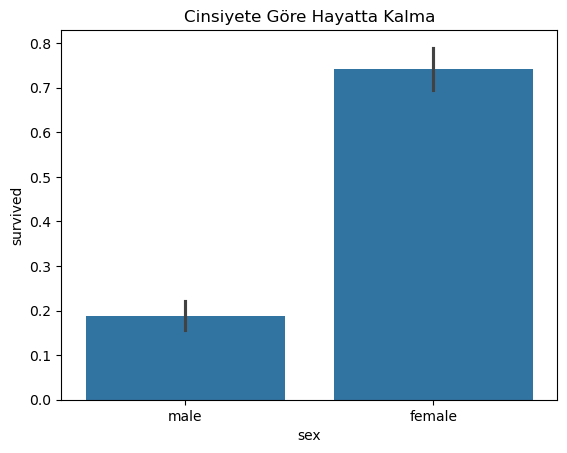

In [57]:
# Cinsiyete göre hayatta kalma oranı (survived:1 yaşayan,0 ölen)
sns.barplot(data=df, x="sex", y="survived")
plt.title("Cinsiyete Göre Hayatta Kalma")
plt.show()

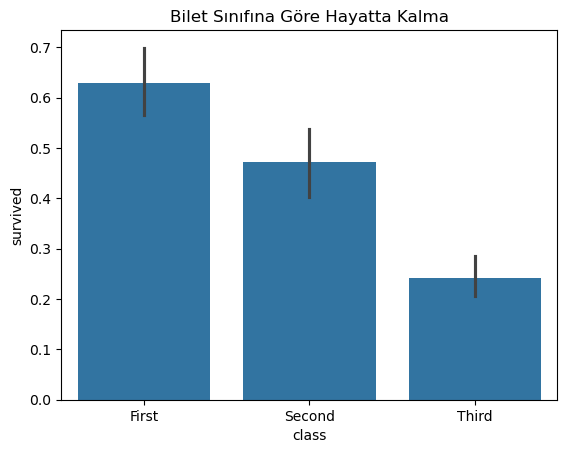

In [58]:
# Bilet sınıfına göre hayatta kalma
sns.barplot(data=df, x="class", y="survived")
plt.title("Bilet Sınıfına Göre Hayatta Kalma")
plt.show()

In [59]:
# Veri setinde boş olan alanların toplamı
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [60]:
# Yaş sütunundaki boş alanları ortalama ile değiştirildi
df["age"] = df["age"].fillna(df["age"].mean())

In [61]:
df["age"].isnull().sum()

0

In [62]:
# İşe yaramayacak sütunların temizlenmesi
df_clean = df.drop(['deck','embark_town','alive','who','adult_male'], axis=1)

In [63]:
df_encoded = pd.get_dummies(df_clean, columns=['sex','embarked','class'], drop_first=True)

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df_encoded.drop("survived", axis=1) 
y = df_encoded["survived"]

In [65]:
# Veri setini bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [67]:
# Tahmin
y_pred = model.predict(X_test)

In [68]:
# Accuracy: Doğruluk Oranı
print(f"Doğruluk oranı: {accuracy_score(y_test,y_pred)}")

Doğruluk oranı: 0.7932960893854749


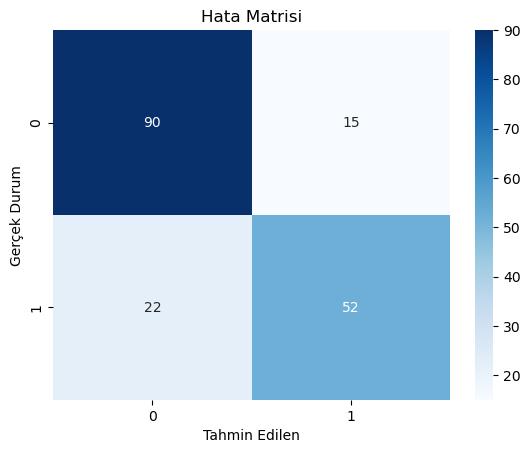

In [69]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Durum')
plt.title('Hata Matrisi')
plt.show()

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest Doğruluk Oranı: {accuracy_score(y_test,y_pred_rf)}")

Random Forest Doğruluk Oranı: 0.8156424581005587


In [73]:
# Modelin hangi özelliğe daha fazla önem verdiği
onem_sirasi = pd.Series(rf_model.feature_importances_, index=X_train.columns)

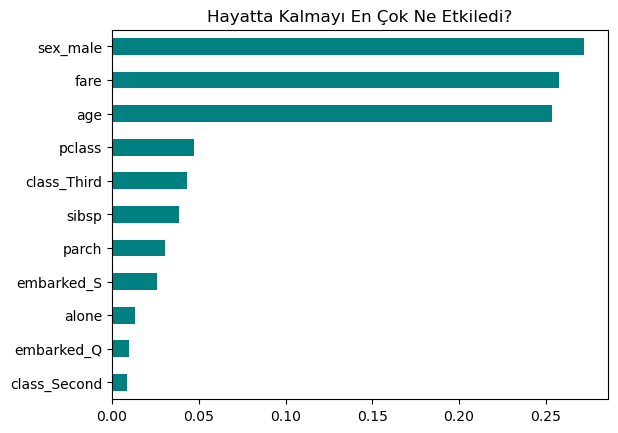

In [74]:
onem_sirasi.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title("Hayatta Kalmayı En Çok Ne Etkiledi?")
plt.show()